In [2]:
import numpy as np
import mpmath
import matplotlib.pyplot as plt
import pygridsynth as gridsynth

from bloqade import squin
from bloqade.cirq_utils import emit_circuit
import cirq

def string_to_unitary(gate_string):
    @squin.kernel
    def circ():
        q = squin.qalloc(1)
        for char in gate_string:
            if char == "H":
                squin.h(q[0])
            elif char == "S":
                squin.s(q[0])
            elif char == "T":
                squin.t(q[0])
            elif char == "X":
                squin.x(q[0])
            elif char == "Y":
                squin.y(q[0])
            elif char == "Z":
                squin.z(q[0])
            # We ignore "W" since it is just a global phase and our distance metric is invariant to it.
        return q
        
    c = emit_circuit(circ, ignore_returns=True)
    # Handle empty circuits safely
    if not c.all_qubits():
        return np.eye(2, dtype=complex)
    return cirq.unitary(c)

def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance(U, V):
    tr = np.trace(U.conj().T @ V)
    val = 1 - np.abs(tr)/2
    if val < 0: val = 0
    return np.sqrt(val)

In [3]:
mpmath.mp.dps = 128
epsilon = mpmath.mpf("1e-4")

exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n)
    
    if n in exact_gates:
        gates = exact_gates[n]
    else:
        # Synthesize with pygridsynth
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=epsilon)
    
    # Evaluate distance
    U_approx = string_to_unitary(gates)
    U_target = rz(theta_val)
    dist = distance(U_target, U_approx)
    
    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S

n=2: target Rz(pi/4)
  Distance: 0.00e+00
  T-count:  1
  Length:   1
  Sequence: T

n=3: target Rz(pi/8)
  Distance: 3.08e-05
  T-count:  44
  Length:   110
  Sequence: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW

n=4: target Rz(pi/16)
  Distance: 3.03e-05
  T-count:  42
  Length:   111
  Sequence: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW

n=5: target Rz(pi/32)
  Distance: 1.80e-05
  T-count:  36
  Length:   97
  Sequence: HTSHTHTHTHTSHTSHTSHTSHTSHTSHTHTHTHTHTHTHTHTSHTHTHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTSHTHTSHTHTHSWWWWWWW



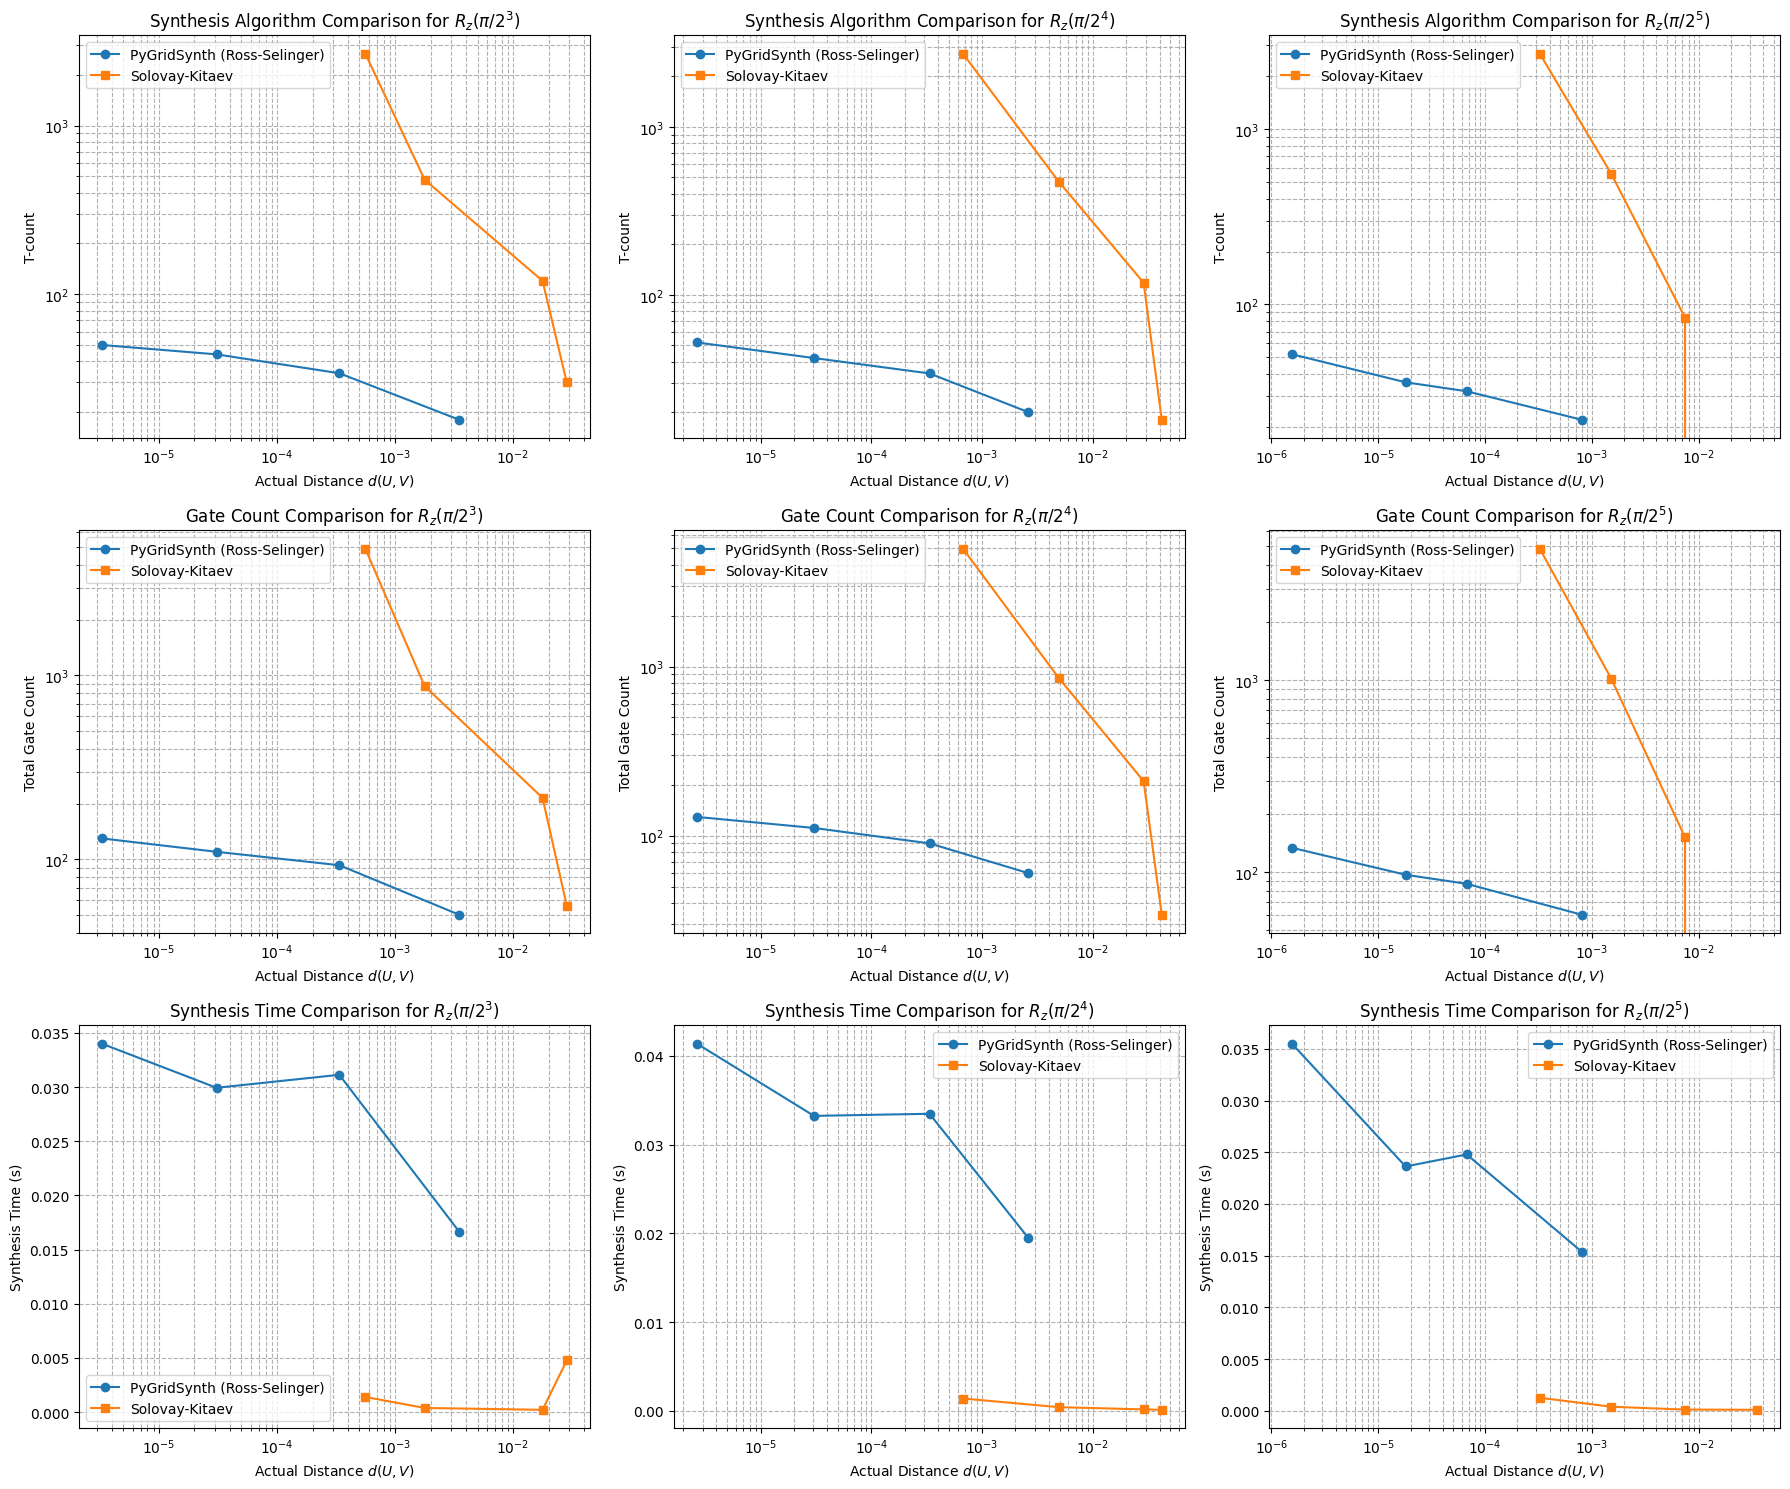

In [4]:
# Comparing PyGridSynth (Ross-Selinger) vs Solovay-Kitaev
import time
from qiskit.synthesis import SolovayKitaevDecomposition
from qiskit.circuit.library import RZGate
from qiskit.quantum_info import Operator

n_values = [3, 4, 5]
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

skd = SolovayKitaevDecomposition()

for i, n_val in enumerate(n_values):
    theta_val = np.pi / (2**n_val)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
    U_target = rz(theta_val)

    # 1. PyGridSynth (Ross-Selinger)
    pg_distances = []
    pg_tcounts = []
    pg_depths = []
    pg_times = []
    epsilons = [mpmath.mpf(f"1e-{k}") for k in range(2, 6)]
    for eps in epsilons:
        start_time = time.time()
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
        end_time = time.time()
        U_approx = string_to_unitary(gates)
        dist = distance(U_target, U_approx)
        pg_distances.append(dist)
        pg_tcounts.append(gates.count("T"))
        pg_depths.append(len(gates))
        pg_times.append(end_time - start_time)

    # 2. Solovay-Kitaev (Qiskit)
    sk_distances = []
    sk_tcounts = []
    sk_depths = []
    sk_times = []
    U_target_sk = RZGate(theta_val).to_matrix()

    # We sweep recursion degrees 1 to 4
    for r in [1, 2, 3, 4]:
        start_time = time.time()
        circuit = skd.run(U_target_sk, recursion_degree=r)
        end_time = time.time()
        op = Operator(circuit).data
        dist = distance(U_target, op)
        
        counts = circuit.count_ops()
        t_count = counts.get("t", 0) + counts.get("tdg", 0)
        depth = sum(counts.values())
        
        sk_distances.append(dist)
        sk_tcounts.append(t_count)
        sk_depths.append(depth)
        sk_times.append(end_time - start_time)

    # T-count plot
    ax_t = axes[0, i]
    ax_t.plot(pg_distances, pg_tcounts, marker="o", label="PyGridSynth (Ross-Selinger)")
    ax_t.plot(sk_distances, sk_tcounts, marker="s", label="Solovay-Kitaev")
    ax_t.set_xscale("log")
    ax_t.set_yscale("log")
    ax_t.set_xlabel("Actual Distance $d(U, V)$")
    ax_t.set_ylabel("T-count")
    ax_t.set_title(f"Synthesis Algorithm Comparison for $R_z(\\pi/2^{{{n_val}}})$")
    ax_t.grid(True, which="both", ls="--")
    ax_t.legend()

    # Depth plot
    ax_d = axes[1, i]
    ax_d.plot(pg_distances, pg_depths, marker="o", label="PyGridSynth (Ross-Selinger)")
    ax_d.plot(sk_distances, sk_depths, marker="s", label="Solovay-Kitaev")
    ax_d.set_xscale("log")
    ax_d.set_yscale("log")
    ax_d.set_xlabel("Actual Distance $d(U, V)$")
    ax_d.set_ylabel("Total Gate Count")
    ax_d.set_title(f"Gate Count Comparison for $R_z(\\pi/2^{{{n_val}}})$")
    ax_d.grid(True, which="both", ls="--")
    ax_d.legend()

    # Time plot
    ax_time = axes[2, i]
    ax_time.plot(pg_distances, pg_times, marker="o", label="PyGridSynth (Ross-Selinger)")
    ax_time.plot(sk_distances, sk_times, marker="s", label="Solovay-Kitaev")
    ax_time.set_xscale("log")
    ax_time.set_yscale("linear")
    ax_time.set_xlabel("Actual Distance $d(U, V)$")
    ax_time.set_ylabel("Synthesis Time (s)")
    ax_time.set_title(f"Synthesis Time Comparison for $R_z(\\pi/2^{{{n_val}}})$")
    ax_time.grid(True, which="both", ls="--")
    ax_time.legend()

plt.tight_layout()
plt.show()

In [5]:
#import mpmath
#import pygridsynth as gridsynth
#from qiskit import QuantumCircuit
#from qiskit.visualization import visualize_transition
#
#n_val = 4
#theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
#eps = mpmath.mpf("1e-5")
#
## Synthesize with pygridsynth
#gates_str = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
#
#qc = QuantumCircuit(1)
#for char in gates_str:
#    if char == "H":
#        qc.h(0)
#    elif char == "S":
#        qc.s(0)
#    elif char == "T":
#        qc.t(0)
#    elif char == "X":
#        qc.x(0)
#    elif char == "Y":
#        qc.y(0)
#    elif char == "Z":
#        qc.z(0)
#
#visualize_transition(
#    circuit=qc, 
#    trace=True,                           # Displays tracing vectors showing the history of 10 past vectors
#    saveas="bloch_rotation_sequence.gif", # Saves the animation as a video to your filesystem
#    fpg=15,                               # Frames per gate for smoother animation (5-30 is recommended for Jupyter)
#    spg=0.5                                 # Number of seconds the animation of individual gate transitions should take
#)

In [6]:
@squin.kernel
def gate_teleportation(psi):
    magic_state = squin.qalloc(1)
    squin.h(magic_state[0])
    squin.t(magic_state[0])

    squin.cnot(psi[0], magic_state[0])

    bit = squin.measure(magic_state[0])

    if bit == 1:
        squin.s(psi[0])
    
    return psi

In [7]:
def string_to_unitary_injection(gate_string):
    @squin.kernel
    def circ():
        q = squin.qalloc(1)
        for char in gate_string:
            if char == "H":
                squin.h(q[0])
            elif char == "S":
                squin.s(q[0])
            elif char == "T":
                squin.gate_teleportation(q[0])
            elif char == "X":
                squin.x(q[0])
            elif char == "Y":
                squin.y(q[0])
            elif char == "Z":
                squin.z(q[0])
            # We ignore "W" since it is just a global phase and our distance metric is invariant to it.
        return q
        
    c = emit_circuit(circ, ignore_returns=True)
    # Handle empty circuits safely
    if not c.all_qubits():
        return np.eye(2, dtype=complex)
    return cirq.unitary(c)

In [ ]:
mpmath.mp.dps = 128
epsilon = mpmath.mpf("1e-4")

exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n)
    
    if n in exact_gates:
        gates = exact_gates[n]
    else:
        # Synthesize with pygridsynth
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=epsilon)
    
    # Evaluate distance
    U_approx = string_to_unitary_injection(gates)
    U_target = rz(theta_val)
    dist = distance(U_target, U_approx)
    
    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S

n=2: target Rz(pi/4)
  Distance: 2.76e-01
  T-count:  1
  Length:   1
  Sequence: T

n=3: target Rz(pi/8)
  Distance: 9.28e-01
  T-count:  44
  Length:   110
  Sequence: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW

n=4: target Rz(pi/16)
  Distance: 1.00e+00
  T-count:  42
  Length:   111
  Sequence: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW

n=5: target Rz(pi/32)
  Distance: 1.00e+00
  T-count:  36
  Length:   97
  Sequence: HTSHTHTHTHTSHTSHTSHTSHTSHTSHTHTHTHTHTHTHTHTSHTHTHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTSHTHTSHTHTHSWWWWWWW

